In [1]:
# Import necessary packages
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import ast

In [2]:
# Read in data, here survival and drug treatment data for TCGA tumors
# And which tumors have mutations in the EGFR cluster of interest
surv = pd.read_csv('survival_data.csv')
EGFR_mut_status = pd.read_csv('EGFR_mut_status_tumors.csv')
clin = pd.read_csv('clinical.csv')

/tmp/kritis/46897236/c0300ood18.ll.unc.edu/ipykernel_2900038/2318332909.py:5: DtypeWarning: Columns (3,10,11,16,66) have mixed types. Specify dtype option on import or set low_memory=False.
  clin = pd.read_csv('clinical.csv')


In [3]:
# Create a dictionary mapping mutation category -> tumor list (as strings)
dict_tumors = dict(zip(EGFR_mut_status['mut'], EGFR_mut_status['tumor']))

# Convert tumor lists from strings into actual Python lists
dict_tumors = {
    group: ast.literal_eval(patients)
    for group, patients in dict_tumors.items()
}

In [4]:
# build patient -> group mapping from your dict
patient_to_group = {}

for group, patients in dict_tumors.items():
    for pid in patients:
        patient_to_group[str(pid)[:12]] = group

# assign group labels
surv['group'] = surv['_PATIENT'].map(patient_to_group)

# keep only patients that appear in your dict
surv = surv.dropna().copy()

# if the same patient appears more than once, keep one row
surv = surv.drop_duplicates(subset=['_PATIENT'])

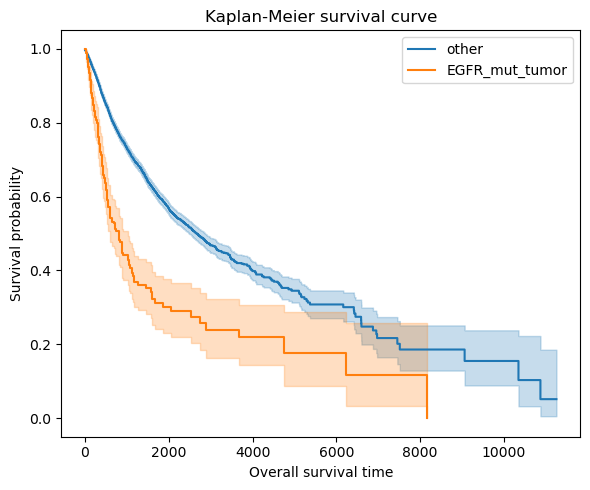

In [5]:
kmf = KaplanMeierFitter()

plt.figure(figsize=(6, 5))

for group in surv['group'].unique():
    sub = surv[surv['group'] == group]
    kmf.fit(
        durations=sub['OS.time'],
        event_observed=sub['OS'],
        label=group
    )
    kmf.plot_survival_function()

plt.xlabel("Overall survival time")
plt.ylabel("Survival probability")
plt.title("Kaplan-Meier survival curve")


plt.tight_layout()
plt.show()

In [6]:
# Get p-val
g1 = surv[surv['group'] == 'EGFR_mut_tumor']
g2 = surv[surv['group'] == 'other']

result = logrank_test(
    g1['OS.time'],
    g2['OS.time'],
    event_observed_A=g1['OS'],
    event_observed_B=g2['OS']
)

print("log-rank p-value:", result.p_value)

log-rank p-value: 1.6164888076125152e-26


In [7]:
# Get tumors treated by paclitaxel and create new dict of EGFR mut tumors
# Treated with pac and not
pac = clin[clin['treatments.therapeutic_agents']=='Paclitaxel']['cases.submitter_id'].tolist()

list_mut = dict_tumors["EGFR_mut_tumor"]
list_mut_pac = [i for i in list_mut if i in pac]
list_mut_not_pac = [i for i in list_mut if i not in list_mut_pac]

dict_pac = {}

dict_pac["EGFR_mut_tumor"]=list_mut_not_pac
dict_pac["pac_treated"]=list_mut_pac

In [8]:
# build patient -> group mapping from your dict
patient_to_group = {}
for group, patients in dict_pac.items():
    for pid in patients:
        patient_to_group[str(pid)[:12]] = group

# assign group labels
surv['group'] = surv['_PATIENT'].map(patient_to_group)

# keep only patients that appear in your dict
surv = surv.dropna().copy()

# if the same patient appears more than once, keep one row
surv = surv.drop_duplicates(subset=['_PATIENT'])

surv2 = surv[surv['OS.time']<=2571.0]

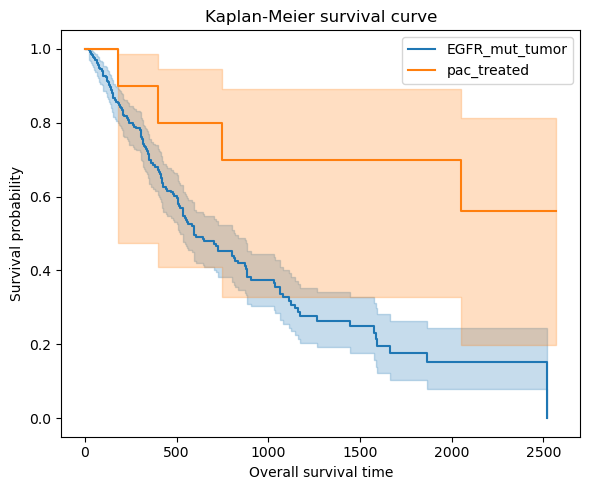

In [9]:
kmf = KaplanMeierFitter()

plt.figure(figsize=(6, 5))

for group in surv2['group'].unique():
    sub = surv2[surv2['group'] == group]
    kmf.fit(
        durations=sub['OS.time'],
        event_observed=sub['OS'],
        label=group
    )
    kmf.plot_survival_function()

plt.xlabel("Overall survival time")
plt.ylabel("Survival probability")
plt.title("Kaplan-Meier survival curve")


plt.tight_layout()
plt.show()

In [10]:
# Get stats
g1 = surv2[surv2['group'] == 'EGFR_mut_tumor']
g2 = surv2[surv2['group'] == 'pac_treated']

result = logrank_test(
    g1['OS.time'],
    g2['OS.time'],
    event_observed_A=g1['OS'],
    event_observed_B=g2['OS']
)

print("log-rank p-value:", result.p_value)

log-rank p-value: 0.009334420995646558
